In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from models.montecarlo import bsm_price_mc
from models.bsm import bsm_price

N=     100: price=10.92886, SE=1.44268, |err|=0.47827
N=    1000: price=9.93777, SE=0.44857, |err|=0.51281
N=   10000: price=10.36288, SE=0.14626, |err|=0.08770
N=  100000: price=10.37351, SE=0.04650, |err|=0.07707
N= 1000000: price=10.42838, SE=0.01469, |err|=0.02221


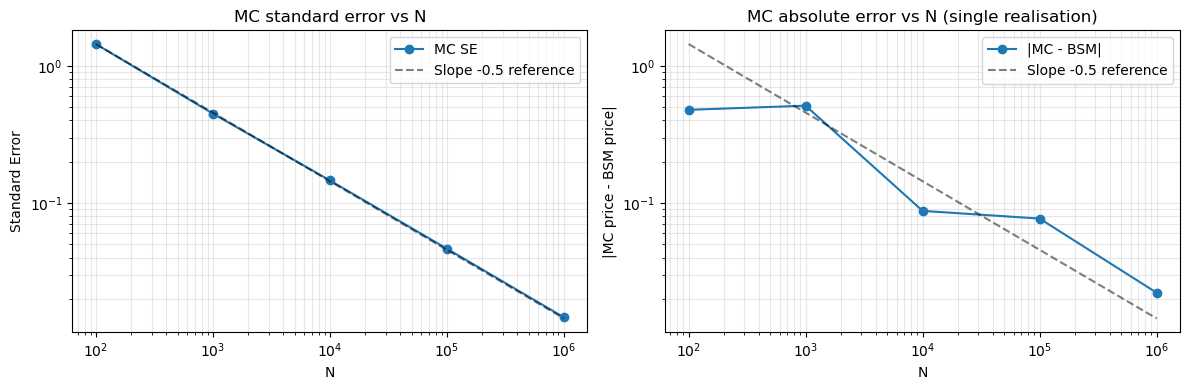

In [2]:
bsm_truth = bsm_price(100, 100, 1.0, 0.05, 0.20, 'call')

Ns = [100, 1_000, 10_000, 100_000, 1_000_000]
results = []
for N in Ns:
    price, se = bsm_price_mc(100, 100, 1.0, 0.05, 0.20, N=N, seed=N)
    err = abs(price - bsm_truth)
    results.append((N, price, se, err))
    print(f"N={N:>8d}: price={price:.5f}, SE={se:.5f}, |err|={err:.5f}")

# Extract for plotting
Ns_arr, prices_arr, ses_arr, errs_arr = zip(*results)
ses_arr = np.array(ses_arr)
errs_arr = np.array(errs_arr)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot SE vs N
axes[0].loglog(Ns_arr, ses_arr, 'o-', label='MC SE')
# Reference line of slope -0.5
ref_x = np.array(Ns_arr, dtype=float)
ref_y = ses_arr[0] * (ref_x[0] / ref_x)**0.5
axes[0].loglog(ref_x, ref_y, 'k--', alpha=0.5, label='Slope -0.5 reference')
axes[0].set_xlabel('N')
axes[0].set_ylabel('Standard Error')
axes[0].set_title('MC standard error vs N')
axes[0].legend()
axes[0].grid(alpha=0.3, which='both')

axes[1].loglog(Ns_arr, errs_arr, 'o-', label='|MC - BSM|')
axes[1].loglog(ref_x, ref_y, 'k--', alpha=0.5, label='Slope -0.5 reference')
axes[1].set_xlabel('N')
axes[1].set_ylabel('|MC price - BSM price|')
axes[1].set_title('MC absolute error vs N (single realisation)')
axes[1].legend()
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

In [3]:
# Compare plain vs antithetic at the same total sample size
N = 100_000

p_plain, se_plain = bsm_price_mc(100, 100, 1.0, 0.05, 0.20, N=N, seed=42, antithetic=False)
p_anti, se_anti = bsm_price_mc(100, 100, 1.0, 0.05, 0.20, N=N, seed=42, antithetic=True)

print(f"Plain     MC: price={p_plain:.5f}, SE={se_plain:.5f}")
print(f"Antithetic MC: price={p_anti:.5f}, SE={se_anti:.5f}")
print(f"SE ratio:     {se_anti / se_plain:.3f}  (lower is better)")
print(f"Variance reduction factor: {(se_plain / se_anti)**2:.2f}x")

Plain     MC: price=10.42054, SE=0.04677
Antithetic MC: price=10.46731, SE=0.03308
SE ratio:     0.707  (lower is better)
Variance reduction factor: 2.00x


N=     100: SE_plain=1.44268, SE_anti=1.00622, ratio=0.697
N=    1000: SE_plain=0.44857, SE_anti=0.30942, ratio=0.690
N=   10000: SE_plain=0.14626, SE_anti=0.10491, ratio=0.717
N=  100000: SE_plain=0.04650, SE_anti=0.03295, ratio=0.709
N= 1000000: SE_plain=0.01469, SE_anti=0.01038, ratio=0.707


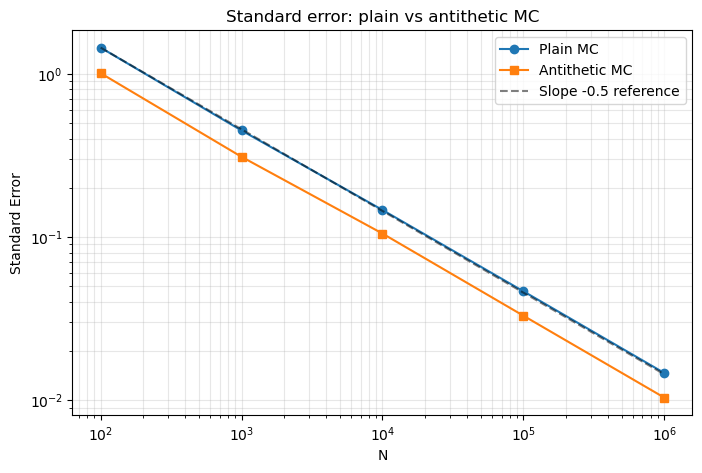

In [4]:
bsm_truth = bsm_price(100, 100, 1.0, 0.05, 0.20, 'call')

Ns = [100, 1_000, 10_000, 100_000, 1_000_000]
plain_se = []
anti_se = []

for N in Ns:
    _, se_p = bsm_price_mc(100, 100, 1.0, 0.05, 0.20, N=N, seed=N, antithetic=False)
    _, se_a = bsm_price_mc(100, 100, 1.0, 0.05, 0.20, N=N, seed=N, antithetic=True)
    plain_se.append(se_p)
    anti_se.append(se_a)
    print(f"N={N:>8d}: SE_plain={se_p:.5f}, SE_anti={se_a:.5f}, ratio={se_a/se_p:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(Ns, plain_se, 'o-', label='Plain MC')
ax.loglog(Ns, anti_se, 's-', label='Antithetic MC')
ref = plain_se[0] * (np.array(Ns, dtype=float)[0] / np.array(Ns, dtype=float))**0.5
ax.loglog(Ns, ref, 'k--', alpha=0.5, label='Slope -0.5 reference')
ax.set_xlabel('N')
ax.set_ylabel('Standard Error')
ax.set_title('Standard error: plain vs antithetic MC')
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.show()

In [5]:
c_same, _ = bsm_price_mc(100, 100, 1.0, 0.05, 0.20, N=10_000, seed=42, option_type='call')
p_same, _ = bsm_price_mc(100, 100, 1.0, 0.05, 0.20, N=10_000, seed=42, option_type='put')
residual_same = c_same - p_same - 100 + 100 * np.exp(-0.05 * 1.0)
print(f"Same seed:      residual = {residual_same:.2e}")

# Different seeds → only satisfies parity within MC noise
c_diff, _ = bsm_price_mc(100, 100, 1.0, 0.05, 0.20, N=10_000, seed=1, option_type='call')
p_diff, _ = bsm_price_mc(100, 100, 1.0, 0.05, 0.20, N=10_000, seed=2, option_type='put')
residual_diff = c_diff - p_diff - 100 + 100 * np.exp(-0.05 * 1.0)
print(f"Different seeds: residual = {residual_diff:.2e}")

Same seed:      residual = -1.80e-01
Different seeds: residual = -7.75e-02


### Note on MC put-call parity

Unlike CRR (which satisfies parity exactly at any N, since it's a deterministic
quadrature), MC parity only holds *in expectation*. For a finite MC sample of
size N, even with the same seed for call and put, the parity residual is a
random quantity with mean zero and stddev ≈ σ·S·e^(rT)·√T/√N.

For N=10,000 above, expected residual stddev ≈ 0.21. Observed residual of
order ~0.1–0.2 is consistent with the theory: parity is holding within MC
noise, not exactly.